In [1]:
# Imports

import os
import sys
import numpy as np
import netCDF4 as nc
from tqdm.auto import tqdm # progress bar
import xarray as xr
import xesmf as xe
from cartopy.crs import PlateCarree
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")
import glob
from matplotlib.colors import ListedColormap, BoundaryNorm
from dask.diagnostics import ProgressBar


In [2]:
ds = xr.open_dataset("/glade/work/netige/Data/VIKING/ssh_obp_variance_products.nc")

In [3]:
ds2 = xr.open_dataset("/glade/work/netige/Data/VIKING/ssh_obp_variance_products2.nc")

In [4]:
ds3 = xr.open_dataset("/glade/work/netige/Data/VIKING/ssh_obp_variance_products3.nc")

In [5]:
viking_ds = xr.open_dataset("/glade/work/netige/Data/VIKING/obp_ssh_rm_dt.nc")

In [6]:
ssh_var = ds.ssh_var
ssh_p_var = ds2.ssh_p_var


In [7]:
#compute std.s from variance
ssh_std = xr.apply_ufunc(np.sqrt, ssh_var) 
ssh_p_std = xr.apply_ufunc(np.sqrt, ssh_p_var) 
dif = ssh_std-ssh_p_std

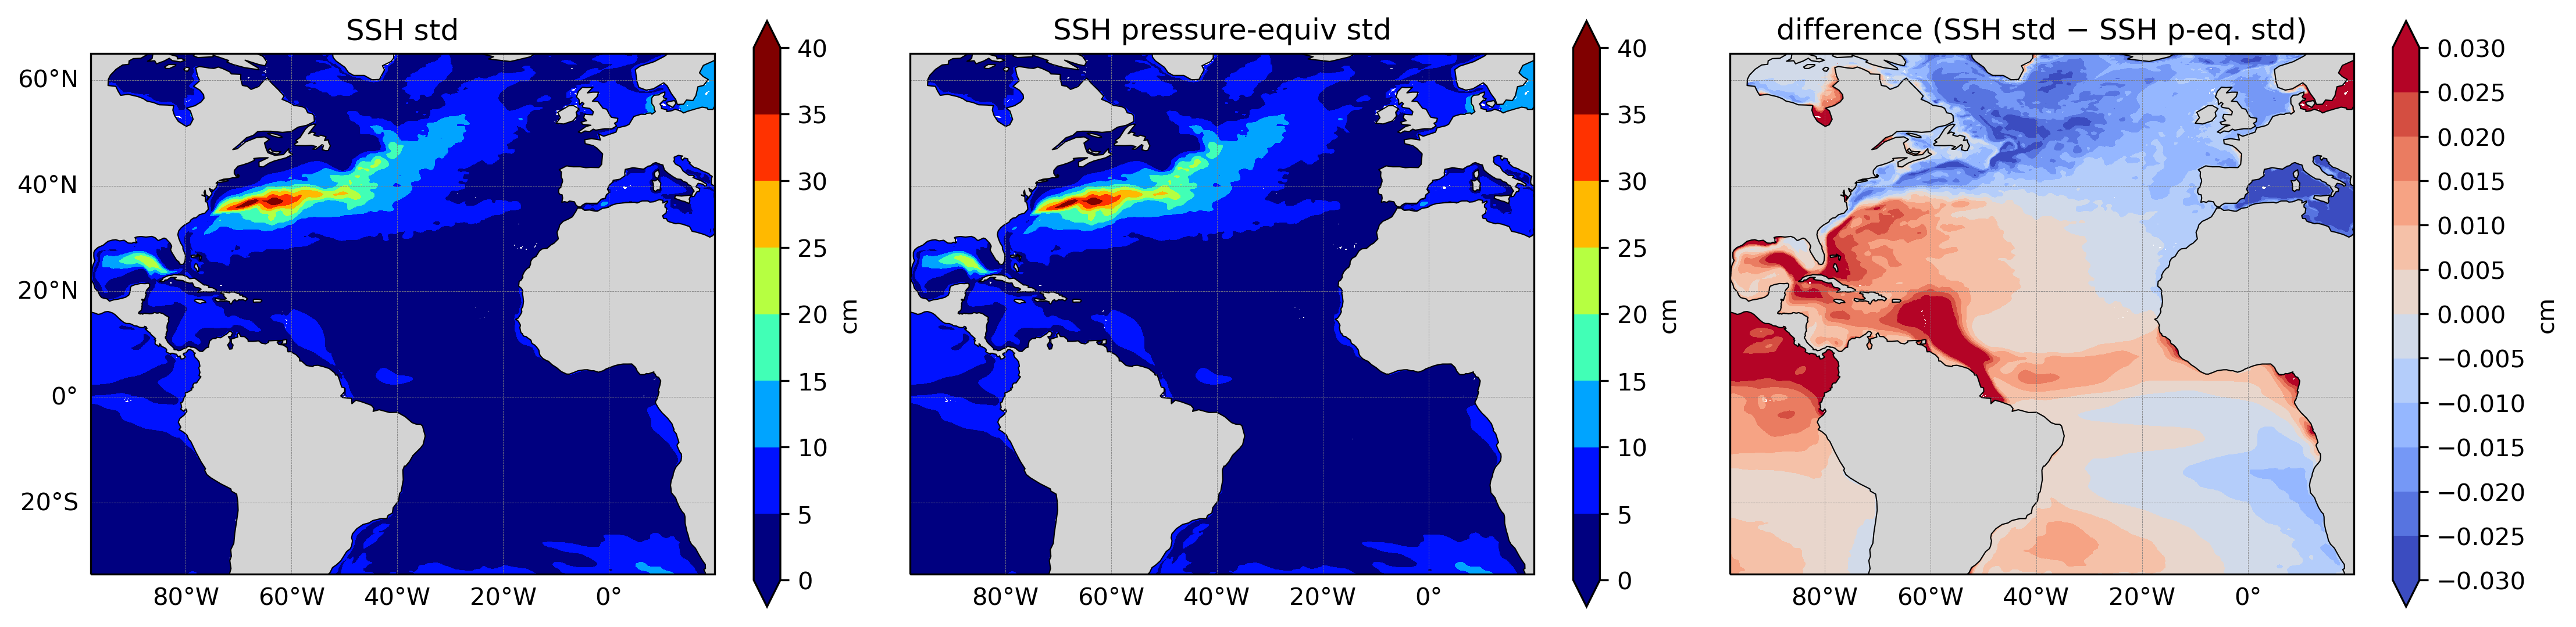

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import BoundaryNorm, ListedColormap

# --- Colormap for std panels (0..40 by 2) ---
boundaries = np.arange(0, 42, 5)      # edges: 0,2,...,40  → 20 bins
base = plt.cm.get_cmap("jet", len(boundaries) - 1)
cmap = ListedColormap(base(np.arange(base.N)))
norm = BoundaryNorm(boundaries, ncolors=cmap.N)

# --- Colormap for difference panel (-0.03..0.03 by 0.005) ---
boundaries2 = np.arange(-0.03, 0.0301, 0.005)   # include 0.03
base2 = plt.cm.get_cmap("coolwarm", len(boundaries2) - 1)
cmap2 = ListedColormap(base2(np.arange(base2.N)))
norm2 = BoundaryNorm(boundaries2, ncolors=cmap2.N)

# Figure & axes
fig, axes = plt.subplots(
    nrows=1, ncols=3, figsize=(15, 4.5), dpi=300,
    subplot_kw=dict(projection=ccrs.PlateCarree(central_longitude=0))
)

fields = [
    (ssh_std,   "SSH std"),
    (ssh_p_std, "SSH pressure-equiv std"),
    (dif,       "difference (SSH std − SSH p-eq. std)")
]

for i, (ax, (da, title)) in enumerate(zip(axes, fields)):
    # Choose the right colormap/norm per panel
    if i < 2:
        pc = ax.pcolormesh(
            da.lon, da.lat, da,
            transform=ccrs.PlateCarree(),
            cmap=cmap, norm=norm, shading="auto"
        )
        cb_ticks = np.arange(0, 41, 5)
        cb_extend = 'both'  # show under/over triangles if any values fall outside
        cb_label = "cm"
    else:
        pc = ax.pcolormesh(
            da.lon, da.lat, da,
            transform=ccrs.PlateCarree(),
            cmap=cmap2, norm=norm2, shading="auto"
        )
        cb_ticks = boundaries2  # or boundaries2[::2] for fewer tick labels
        cb_extend = 'both'
        cb_label = "cm"

    # Map decorations
    ax.add_feature(
        cfeature.NaturalEarthFeature('physical', 'land', '110m',
                                     linewidth=0.5, edgecolor='black',
                                     facecolor='lightgray')
    )
    gl = ax.gridlines(color='gray', linestyle='--', linewidth=0.2, draw_labels=False)
    gl.top_labels = False
    gl.right_labels = False
    if i == 0:
        gl.left_labels = True
        gl.bottom_labels = True
    else:
        gl.left_labels = False
        gl.bottom_labels = True
    ax.set_title(title, fontsize=12)

    # Colorbar
    cb = fig.colorbar(pc, ax=ax, orientation='vertical', shrink=0.8,
                      ticks=cb_ticks, extend=cb_extend)
    cb.set_label(cb_label, fontsize=10)

plt.tight_layout()
plt.savefig("VIKING_OBP_Comp.png", dpi=500, bbox_inches='tight')
plt.show()


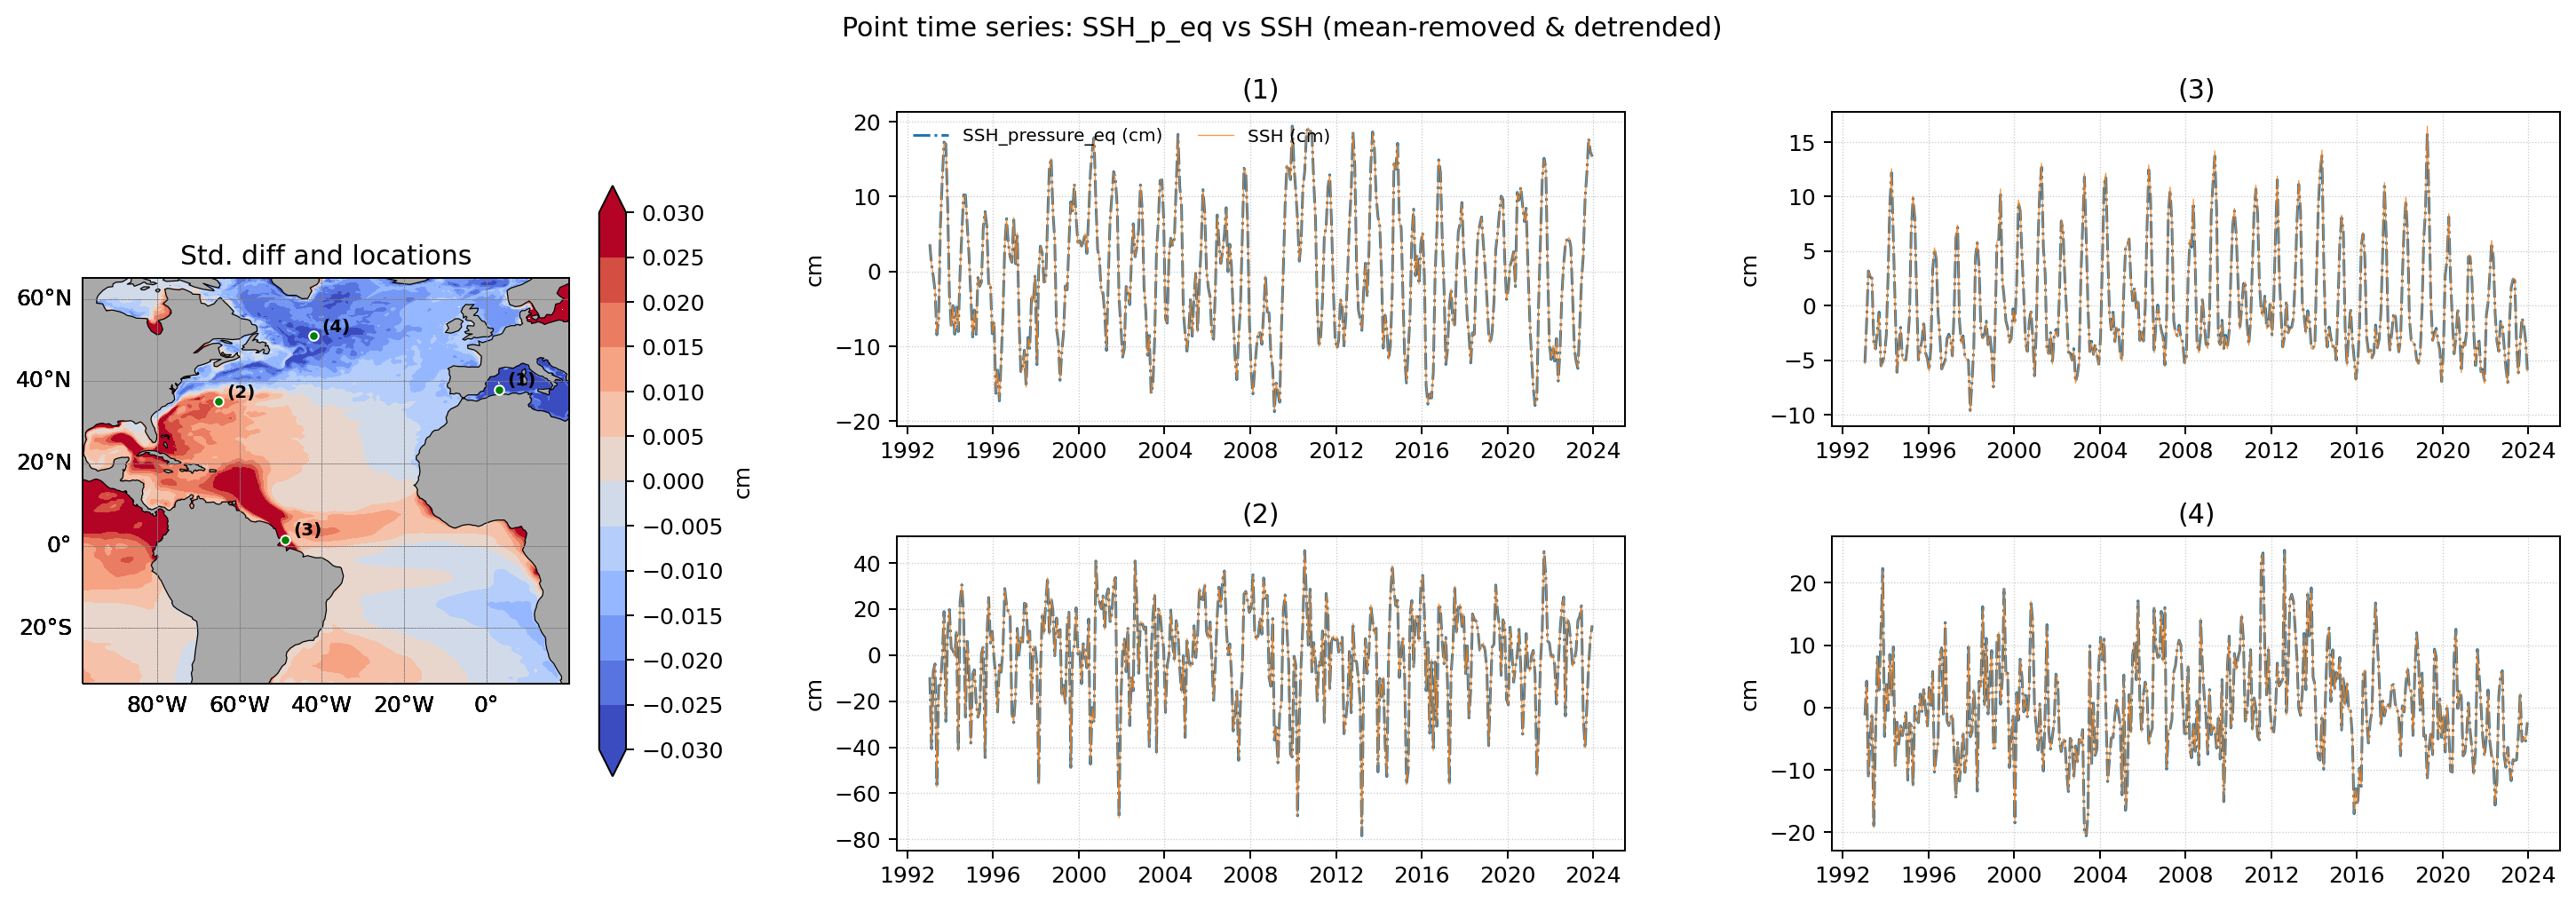

In [39]:
# --- build nearest indices exactly as before, but DO NOT compute any 2-D raster ---
lat1d = viking_ds["lat"]; lon1d = viking_ds["lon"]

def nearest_index_1d(coord, v):
    arr = coord.values
    j = np.searchsorted(arr, v)
    if j == 0: return 0
    if j >= arr.size: return arr.size - 1
    return j if abs(arr[j]-v) < abs(arr[j-1]-v) else j-1

sites = {
    "(1)":       ( 3.0, 38.0),
    "(2)":  (-65.0, 35.0),
    "(3)":       (-49.0, 1.5),
    "(4)":  (-42.0, 51.0),
}

# Extract only the four 1-D series (tiny compute)
ssh_p = viking_ds["ssh_p_rm_dt"]; ssh = viking_ds["ssh_rm_dt"]
ts = {}
for name, (lo, la) in sites.items():
    i = nearest_index_1d(lon1d, lo)
    j = nearest_index_1d(lat1d, la)
    ts[(name,"SSH_pressure_eq")] = ssh_p.isel(lon=i, lat=j).compute()
    ts[(name,"SSH")]   = ssh.isel(lon=i, lat=j).compute()

# Plot: coastlines-only locator + 4 TS
import matplotlib.pyplot as plt
import cartopy.crs as ccrs, cartopy.feature as cfeature

fig = plt.figure(figsize=(20,6), dpi=180)
gs  = fig.add_gridspec(2,3, width_ratios=[1,1.2,1.2], wspace=0.3, hspace=0.35)

ax_map = fig.add_subplot(gs[:,0], projection=ccrs.PlateCarree())
#ax_map.coastlines("110m", lw=0.7)
ax_map.add_feature(
    cartopy.feature.NaturalEarthFeature('physical', 'land', '110m',
                                        linewidth=0.5,
                                        edgecolor='black',
                                        facecolor='darkgray'))
for name, (lo, la) in sites.items():
    ax_map.scatter(lo, la, s=18, c="green", ec="white", lw=0.8,
                   transform=ccrs.PlateCarree(), zorder=5)
    ax_map.pcolormesh(
            dif.lon, dif.lat, dif,
            transform=ccrs.PlateCarree(),
            cmap=cmap2, norm=norm2, shading="auto")
    ax_map.text(lo+2, la+1, name, transform=ccrs.PlateCarree(),
                fontsize=8, weight="bold")
                #bbox=dict(facecolor="white", alpha=0.7, lw=0))
    gl = ax_map.gridlines(color='gray', linestyle='--', linewidth=0.2, draw_labels=False)
    gl.bottom_labels = True
    gl.left_labels = True
    cb_ticks = boundaries2  # or boundaries2[::2] for fewer tick labels
    cb_extend = 'both'
    cb_label = "cm"
    
ax_map.set_title("Std. diff and locations")

cb = fig.colorbar(pc, ax=ax_map, orientation='vertical', shrink=0.8,
                      ticks=cb_ticks, extend=cb_extend)
cb.set_label(cb_label, fontsize=10)

axs = [fig.add_subplot(gs[0,1]), fig.add_subplot(gs[1,1]),
       fig.add_subplot(gs[0,2]), fig.add_subplot(gs[1,2])]
for ax, name in zip(axs, sites.keys()):
    t = ts[(name,"SSH_pressure_eq")]["time"].values
    ax.plot(t, ts[(name,"SSH_pressure_eq")].values, linestyle = '-.', lw=1.2, label="SSH_pressure_eq (cm)")
    ax.plot(t, ts[(name,"SSH")].values,   lw=0.5, label="SSH (cm)", alpha=0.85)
    ax.grid(True, ls=":", lw=0.5, alpha=0.7)
    ax.set_ylabel("cm"); ax.set_title(name)
axs[0].legend(ncol=2, fontsize=8, frameon=False, loc="upper left")

plt.suptitle("Point time series: SSH_p_eq vs SSH (mean-removed & detrended)", y=0.98)
plt.savefig("VIKING_OBP_Comp2.png", dpi=500, bbox_inches='tight')
plt.tight_layout()
plt.show()


In [2]:
ds3 = xr.open_dataset("/glade/work/netige/Data/VIKING/ssh_obp_variance_products3.nc")

In [4]:
obp_ssh_dif_var = ds3.obp_ssh_dif_var
obp_var = ds3.obp_var

In [5]:
PVE3 = (1-(obp_ssh_dif_var/obp_var))*100

(array([8.700000e+01, 3.020000e+02, 1.583000e+03, 2.342000e+03,
        3.451000e+03, 1.296900e+04, 6.033300e+04, 1.859270e+05,
        8.309180e+05, 2.909663e+06]),
 array([-66775.484  , -60087.97   , -53400.453  , -46712.938  ,
        -40025.418  , -33337.902  , -26650.387  , -19962.871  ,
        -13275.355  ,  -6587.8394 ,     99.67677], dtype=float32),
 <BarContainer object of 10 artists>)

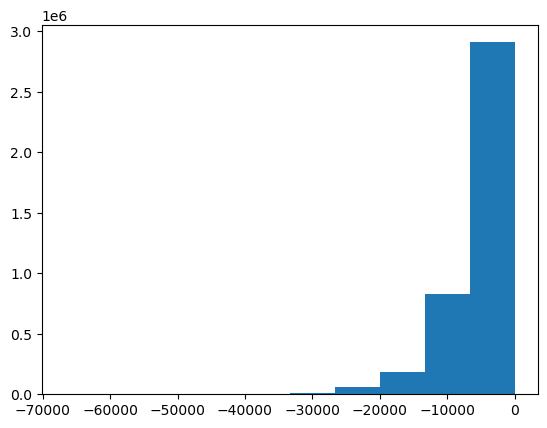

In [6]:
PVE3.plot.hist()

In [7]:
bathy = xr.open_dataset('/glade/work/netige/Data/Bathymetry/GLO-MFC_001_030_mask_bathy.nc')

In [8]:
data32 = bathy["deptho"].astype("float32")            # meters, positive down
data32 = data32.where(np.isfinite(data32)) 

data32 = data32.sel(
    latitude=slice(-33.5, 65),
    longitude=slice(-98, 20)
)


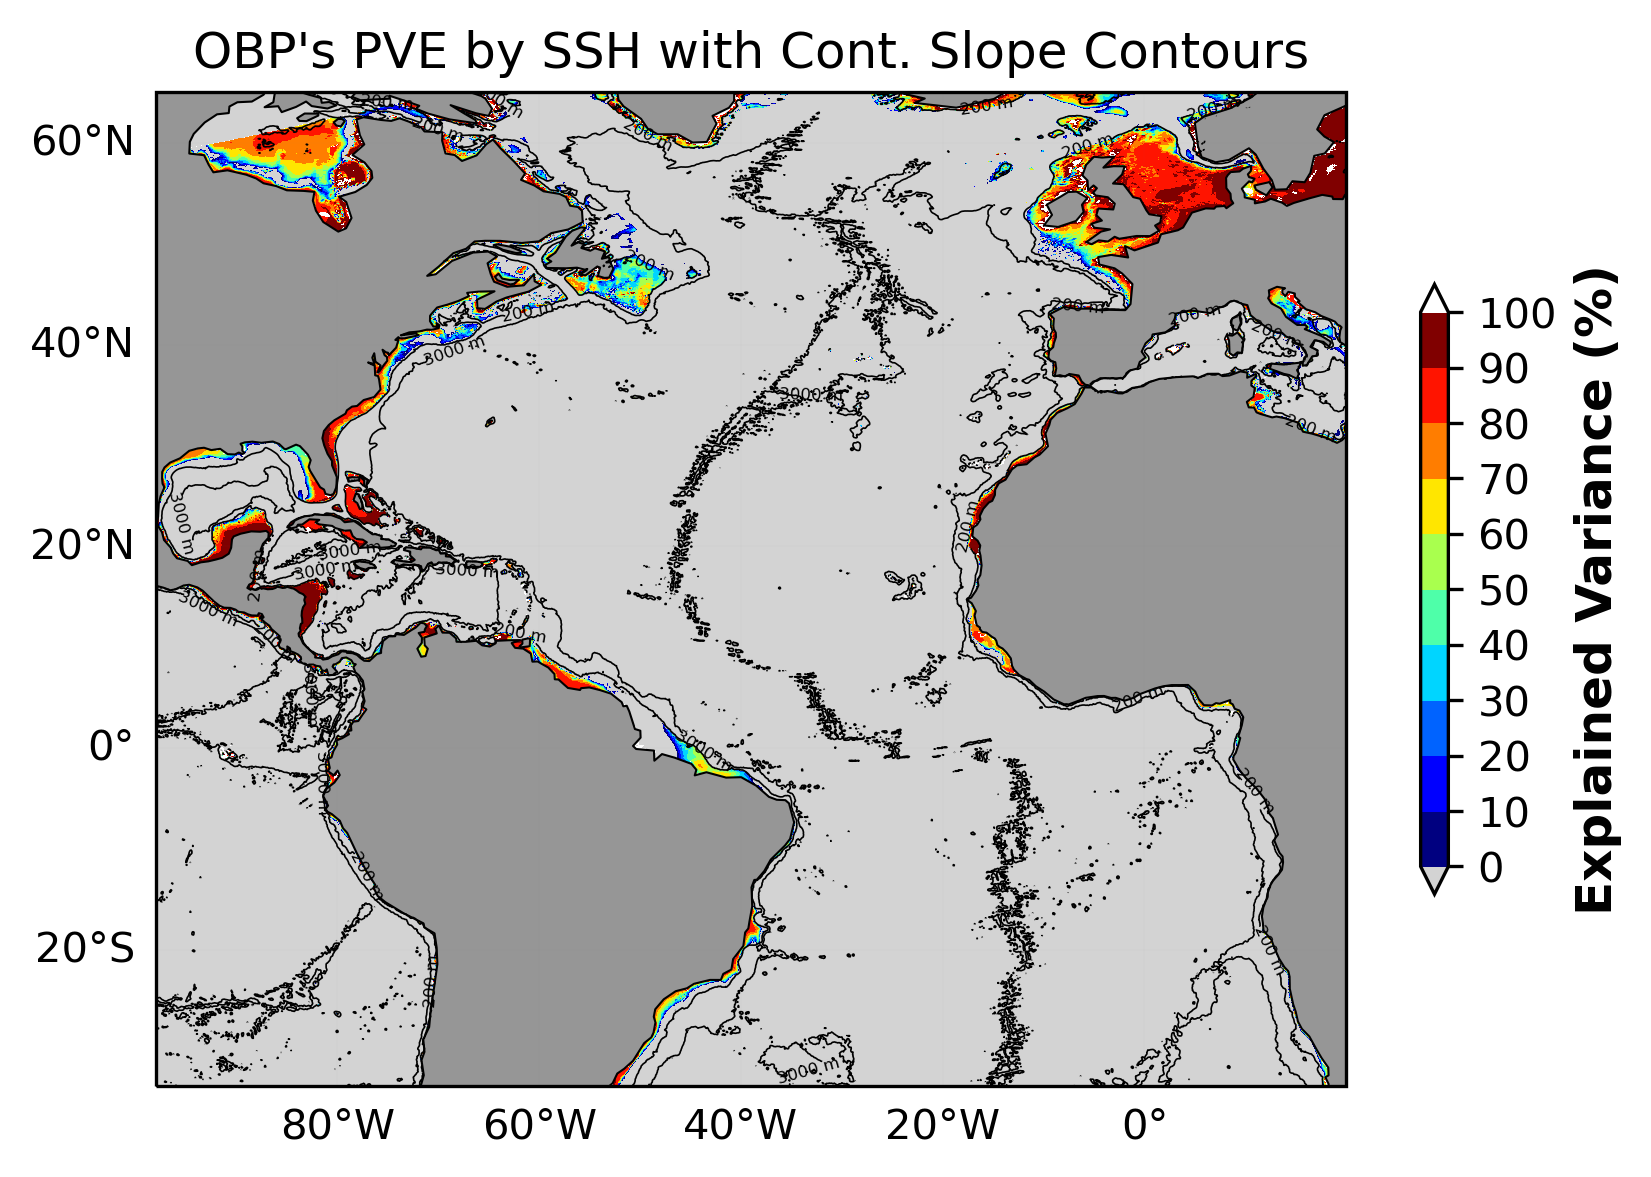

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import BoundaryNorm, ListedColormap

# ----- Build discrete jet colormap for PVE -----
boundaries = np.arange(0, 110, 10)     # 0..100 by 10 → 10 bins
n_bins = len(boundaries) - 1
base = plt.cm.get_cmap("jet", n_bins)
cmap = ListedColormap(base(np.arange(base.N)))
cmap.set_under("lightgray")            # < 0 → light gray
cmap.set_over("white")              # > 100 → darker gray
cmap.set_bad("white")
norm = BoundaryNorm(boundaries, ncolors=cmap.N)

# ----- Bathymetry to float32 & mask -----
           # mask land/invalid if needed

# (Optional) speed-up contours by coarsening the bathy grid:
# data32_c = data32.coarsen(latitude=2, longitude=2, boundary="trim").mean()
# b_lat = data32_c["latitude"]; b_lon = data32_c["longitude"]; b_field = data32_c
b_lat = data32["latitude"]; b_lon = data32["longitude"]; b_field = data32

# ----- Plot -----
fig = plt.figure(dpi=300)
ax = plt.subplot(1, 1, 1, projection=ccrs.PlateCarree(central_longitude=0))

# Your PVE field (0–100 with under/over grays)
pc = ax.pcolormesh(
    PVE3.lon, PVE3.lat, PVE3,
    transform=ccrs.PlateCarree(),
    cmap=cmap, norm=norm, shading="auto"
)

# Bathymetry contours (in meters)
#levels = [200, 1000, 2000, 3000, 4000]
levels = [200, 3000]
cs = ax.contour(
    b_lon, b_lat, b_field,
    levels=levels, colors="k", linewidths=0.4,
    transform=ccrs.PlateCarree()
)
ax.clabel(cs, fmt="%d m", fontsize=4)

# Map decoration
gl = ax.gridlines(color='gray', linestyle='dashed', linewidth=0.01)
gl.xlabels_bottom = True
gl.ylabels_left = True
ax.add_feature(cfeature.NaturalEarthFeature('physical', 'land', '110m',
                                            linewidth=0.5, edgecolor='black',
                                            facecolor='#969696'))

cb = plt.colorbar(pc, shrink=0.55, extend='both', ticks=np.arange(0, 110, 10))
cb.set_label("Explained Variance (%)", fontsize=12, fontweight="bold")

plt.title("OBP's PVE by SSH with Cont. Slope Contours")
plt.savefig("OBP_PVE_by_SSH_cont.png", dpi=500, bbox_inches='tight')

plt.show()
